# Practical Session 5 - Parallel Markov chains with multiprocessing and dask

Students (pair):
- [Student 1]([link](https://github.com/username1))
- [Student 2]([link](https://github.com/username2))


**Useful references for this lab**:

[1] `seaborn`: [official tutorial](https://seaborn.pydata.org/tutorial.html)

[2] `multiprocessing`: [documentation](https://docs.python.org/3/library/multiprocessing.html), [doc2](https://he-arc.github.io/livre-python/multiprocessing/index.html)

[3] `dask`: [documentation](http://numba.pydata.org/) 

## <a name="content">Contents</a>
- [Exercise 1: seaborn, a useful tool for data visualisation](#ex1)
- [Exercise 2: Simulating a discrete-time homogeneous Markov chain](#ex2)
- [Bonus: Parallel computing with Dask](#bonus)
---

In [3]:
%load_ext autoreload
%autoreload 2

## <a name="ex1">Exercise 1: seaborn, a useful tool for data visualisation</a> [(&#8593;)](#content)
 
The `seaborn` package can significantly enhance data and data analysis visualization. See the [tutorial page](https://seaborn.pydata.org/tutorial.html) for examples of effective predefined graphics. An example aimed at visualizing the empirical distributions of 9 realizations of a bivariate Gaussian random vector is reported below.

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11332\1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11332\1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11332\1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_11332\1573286285.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; settin

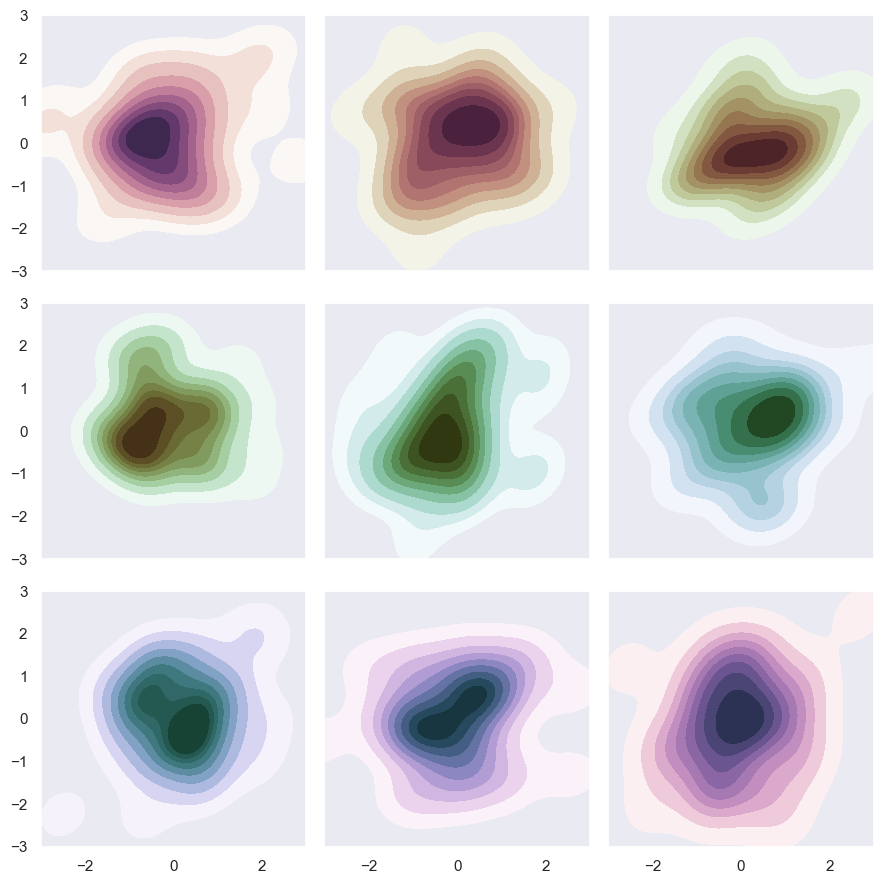

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set(style="dark")
rng = np.random.default_rng(50)

# Set up the matplotlib figure
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Rotate the starting point around the cubehelix hue circle
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):

    # Create a cubehelix colormap to use with kdeplot
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Generate and plot a random bivariate dataset
    x, y = rng.normal(size=(2, 50))
    sns.kdeplot(x=x, y=y, cmap=cmap, shade=True, cut=5, ax=ax)
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

f.tight_layout()

1. Comment on the lines of codes related to the `seaborn` library to make their role explicit. More specifically comment on the KDE method.

**Answer:**

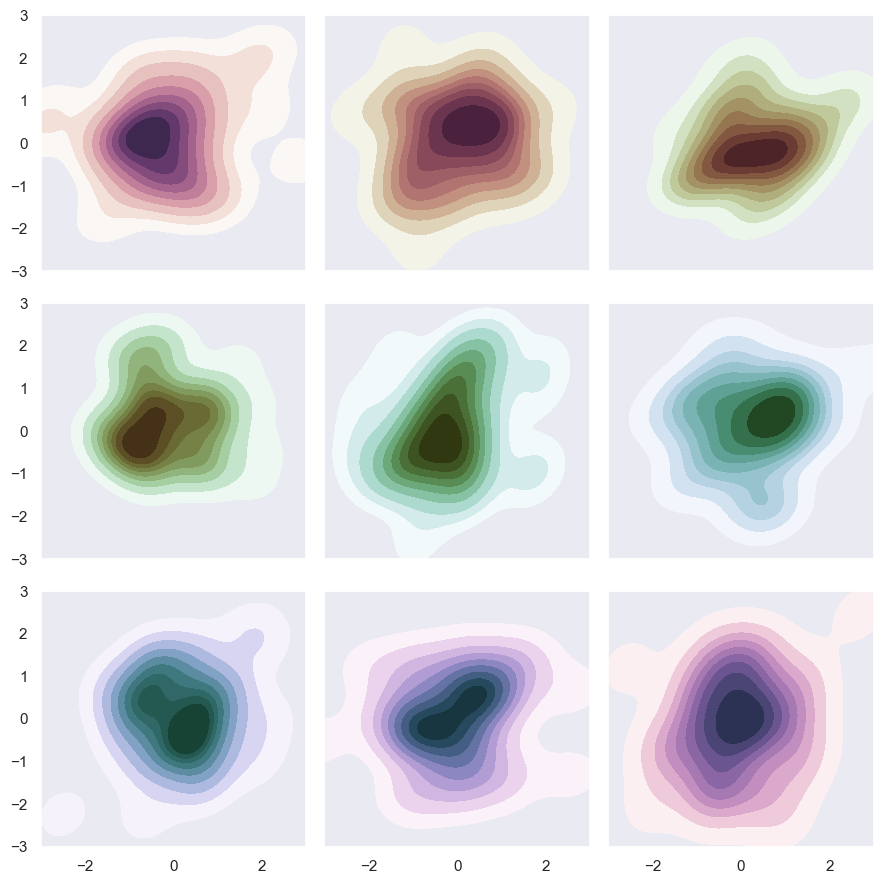

In [5]:
sns.set_theme(style="dark") # suposed to set the background to a dark theme
rng = np.random.default_rng(50)

# Set up the matplotlib figure
# Create a 3x3 figure, composed of nine subplots
f, axes = plt.subplots(3, 3, figsize=(9, 9), sharex=True, sharey=True)

# Rotate the starting point around the cubehelix hue circle
for ax, s in zip(axes.flat, np.linspace(0, 3, 10)):
    # s will be used as the starting point of the cubehelix_palette, giving a slightly different color to each subplot

    # Create a cubehelix colormap to use with kdeplot
    cmap = sns.cubehelix_palette(start=s, light=1, as_cmap=True)

    # Generate and plot a random bivariate dataset
    x, y = rng.normal(size=(2, 50)) # Generate 50 samples following a 2D normal distribution
    sns.kdeplot(x=x, y=y, cmap=cmap, fill=True, cut=5, ax=ax) # shade is now deprecated, fill is the new argument
    # sns.kdeplot estimates the underlying distribution, smoothing the data.
    ax.set(xlim=(-3, 3), ylim=(-3, 3))

f.tight_layout()

2. For one of the realizations, take a look at the documentation of [`sns.jointplot`](https://seaborn.pydata.org/examples/joint_kde.html) to display both the 2-D empirical distribution of the data, and 1D histograms of their distribution along each axis. 

**Answer:**

           0         1
0   0.603066 -1.222715
1   0.568759 -0.358789
2   0.014440  0.093083
3  -0.287660 -1.247167
4  -0.184298  0.425432
5   0.255570 -1.821938
6  -0.441485  1.616789
7  -0.459964 -1.278173
8   0.386589  0.619855
9   0.482547 -0.664024
10  0.187542 -0.321766
11 -0.803080 -1.050710
12 -0.466856 -1.533986
13  0.410342  0.259369
14 -0.179448 -0.460790
15  0.607339 -0.011779
16  0.913913 -2.560674
17 -0.290454  0.906501
18 -0.855894 -0.784624
19  0.589639  1.079868
20  0.380079  0.512178
21 -0.199925 -0.226993
22 -1.265221  1.611834
23  0.015514  0.598902
24 -0.943563 -0.459574
25 -0.995204 -1.002840
26 -0.131773  0.050121
27  0.071525  0.012151
28 -1.054303 -0.055466
29  0.724805 -0.504240
30 -0.889507 -0.687544
31  0.866046 -0.952728
32 -1.604003 -0.350417
33 -0.207195  0.951140
34 -0.310811  0.023871
35  1.738649 -1.682507
36 -1.079546 -1.930018
37 -0.406832 -0.625923
38 -0.528019  0.856031
39  0.369423  0.624771
40  0.360916 -0.920414
41  1.412103  0.466890
42 -0.98715

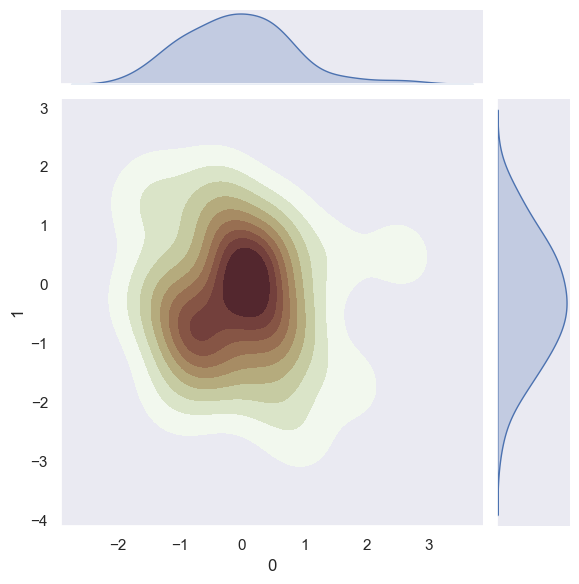

In [6]:
import pandas as pd

r = rng.normal(size=(2,50))
df = pd.DataFrame(np.swapaxes(r, axis1=0, axis2=1)) # converting the data into a DataFrame

print(df)

cmap = sns.cubehelix_palette(start=0.6, light=1, as_cmap=True)

g = sns.jointplot(data=df, x=0, y=1, kind='kde', cmap=cmap, fill=True)

## <a name="ex2">Exercise 2: Simulating a discrete-time homogeneous Markov chain.</a> [(&#8593;)](#content)


Let ${(X_n)}_{n\geq 0}$ be a discrete-time homogeneous Markov chain with values over a finite ensemble $E=\{x_1,\dots,x_N\}$ identified to $\{1,\dots,N\}$. Consider $\boldsymbol{\rho} \in \Delta_N$, where $\Delta_N = \{\mathbf{x}\in\mathbb{R}^N \mid x_n \geq 0 \, \forall n \in \{1,\dotsc,N\} \text{ and } \sum_n x_n = 1 \}$ is the unit simplex in $\mathbb{R}^N$.

In the following, we consider the initial state of the chain $X_0$, following the discrete probability distribution:

$$
    \mathbb{P}(X_0 = k) = \rho_k, \qquad k \in \{1, \dots,  N\}.
$$
  
Let $\mathbf{A} = [a_{i,j}]_{i,j} \in \mathbb{R}^{N \times N}$ be the transition matrix of the chain, i.e.,

\begin{align*}
    &a_{i,j} = \mathbb{P}(X_{n+1} = j \mid X_{n} = i) \geq 0, \, \forall n \geq 0, \\
    &(\forall i \in \{1, \dotsc, N\}), \quad \sum_{j=1}^N a_{i,j} = 1.
\end{align*}
 
The chain is said to be homogeneous in that $\mathbf{A}$ does not depend from the time index $n$. Let $\tilde{a}_n$ represent the $n$-th row of $\mathbf{A}$. 

The trajectory of the chain can be simulated as follows:

>- Draw the discrete random variable $X_0$ with distribution $\boldsymbol{\rho}$;
>
>- For $q = 0$ to $n_{\text{iter}}-1$
>    - Draw the discrete random variable $X_{q+1}$ with distribution $\tilde{a}_{X_{q}}$;
>    
>- Return ${(X_q)}_{0 \leq q \leq n_{\text{iter}}}$.


<!-- If $X_n = k$, we know that $T$, the life time of the chain in the state $k$ obeys a geometric distribution with parameter $a_{kk}$. We also know that the probability of transition from k to $\ell\neq k$ is given by:

$$
    \mathbb{P}(X_{n+1}=\ell | X_n=k, \ell\neq k) = \frac{a_{k\ell}}{1-a_{kk}}.
$$

 ### One possible algorithm to simulate a Markov chain is therefore:

    a. generate the initial state $X_0$ according to the discrete law $\{\rho_1,\dots,\rho_N\}$.

    b. at instant $n$, knowing that $X_n=k$,

    i) determine the life time $T$ in state $X_n=k$ by simulating a geometrical variable with parameter $a_{kk}$. As a consequence $X_n = \dots = X_{n+T} = k$. When $T=0$, we simply still have $X_n=k$.

    ii) determine next transition instant $n+T$, and determine the next state by using the probabilities of transition. -->

1. Implement the above algorithm in a function `X = markov(rho,A,nmax,rng)` with:
     - `rho`: law of the initial state (nonnegative vector of size $N$, summing to 1),
     - `A`: transition matrix (of size $N\times N$) 
     - `nmax`: number of time steps,
     - `rng`: random number generator
     - `X`: trajectory of the chain.
     
In particular, check the input parameters `A` and `rho` make sense by adding appropriate assertions (or raising exceptions).
   - Examples : **transition matrix `A` should be square** ; **expected `A` to be a stochastic matrix** ; **verify if the size of `A` and `rho` are consistent** ; **verify if `rho` is in the unit simplex**
     - `np.allclose`, `np.isclose` and `np.all` could be useful

> Hints:
> - the function `np.random.choice` can be useful to draw discrete random variables.
> - use `states = np.arange(N)` to create the the labels of the states (from $0$ up to $N-1$)

Here is an example of execution : 
![alternatvie text](img/For_CourseM.png)

**Answer:**

In [7]:
def markov(rho,A,nmax,rng) :
    """
    Simulate a discrete-time homogeneous Markov chain.

    Parameters
    ----------
    rho : array-like, shape (N,)
        Initial probability distribution over states (must sum to 1).
    A : array-like, shape (N, N)
        Transition matrix (each row must sum to 1).
    nmax : int
        Number of time steps to simulate.
    rng : np.random.Generator
        Random number generator (e.g. np.random.default_rng()).

    Returns
    -------
    X : np.ndarray, shape (nmax+1,)
        The trajectory of the Markov chain.
    """

    # Convert inputs to numpy arrays
    rho = np.asarray(rho)
    A = np.asarray(A)

    # Checking that every inputs respect certain conditions
    # Check that A is a square matrix
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("Transition matrix A must be square (N x N).")

    N = A.shape[0]

    # Check rho size consistency
    if rho.shape[0] != N:
        raise ValueError("rho must have length N equal to A.shape[0].")

    # Check that rho is a valid probability vector (nonnegative, sums to 1)
    if np.any(rho < 0) or not np.isclose(np.sum(rho), 1):
        raise ValueError("rho must be a valid probability vector (nonnegative and sum to 1).")

    # Check that each row of A sums to 1 and has nonnegative entries
    if np.any(A < 0) or not np.allclose(np.sum(A, axis=1), 1):
        raise ValueError("Each row of A must define a probability distribution (nonnegative and sum to 1).")

    # ---- SIMULATION ----
    states = np.arange(N)            # State labels {0, 1, ..., N-1}
    X = np.zeros(nmax + 1, dtype=int)  # Store trajectory

    # Draw initial state X_0 ~ rho
    X[0] = rng.choice(states, p=rho)

    # Generate the sequence
    for q in range(nmax):
        current_state = X[q]
        # Draw next state X_{q+1} ~ A[current_state, :]
        X[q + 1] = rng.choice(states, p=A[current_state, :])

    return X

2. Set the random number generator to a known state. Make a few simulations using simple transition matrices (*i.e.*, taking any nonnegative matrix $A=(a_{i,j})$ such that its lines sum to 1) and display the trajectory of the chains.

**Answer:**

Trajectory (A1): [1 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1 1 0 0 0 0]
Trajectory (A2): [0 1 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0]
Trajectory (A3): [0 0 1 1 2 2 1 1 0 0 0 0 1 2 2 2 2 2 1 1 2 2 2 2 1 0 1 2 2 1 2]


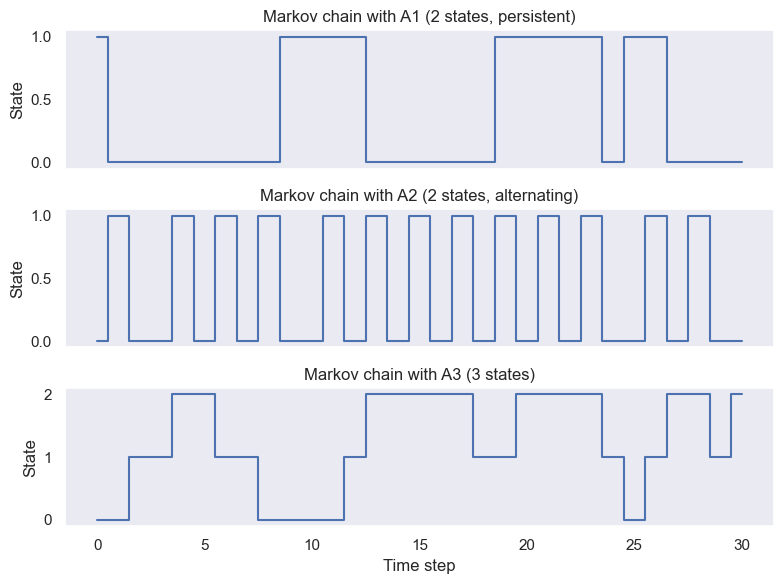

In [8]:
# Define some simple transition matrices
A1 = np.array([[0.8, 0.2],    # High chance to stay in the same state
               [0.3, 0.7]])

A2 = np.array([[0.1, 0.9],    # High switching tendency
               [0.9, 0.1]])

A3 = np.array([[0.5, 0.5, 0.0],   # Three-state chain
               [0.2, 0.5, 0.3],
               [0.0, 0.6, 0.4]])

# Initial probability distributions
rho2 = np.array([0.6, 0.4])
rho3 = np.array([1.0, 0.0, 0.0])  # Start in state 0

# Simulate trajectories
X1 = markov(rho2, A1, nmax=30, rng=rng)
X2 = markov(rho2, A2, nmax=30, rng=rng)
X3 = markov(rho3, A3, nmax=30, rng=rng)

# 5️⃣ Display the trajectories
print("Trajectory (A1):", X1)
print("Trajectory (A2):", X2)
print("Trajectory (A3):", X3)

# 6️⃣ Plot the trajectories
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

axes[0].step(range(len(X1)), X1, where='mid')
axes[0].set_title("Markov chain with A1 (2 states, persistent)")
axes[0].set_ylabel("State")

axes[1].step(range(len(X2)), X2, where='mid')
axes[1].set_title("Markov chain with A2 (2 states, alternating)")
axes[1].set_ylabel("State")

axes[2].step(range(len(X3)), X3, where='mid')
axes[2].set_title("Markov chain with A3 (3 states)")
axes[2].set_xlabel("Time step")
axes[2].set_ylabel("State")

plt.tight_layout()
plt.show()

3. Explore the potential of the [`multiprocessing` package](https://docs.python.org/3/library/multiprocessing.html) to simulate several Markov chains in parallel.

> Hint: the `mutiprocessing.Pool.starmap` or `mutiprocessing.Pool.starmap_async` methods could be useful.

**Answer:**

In [ ]:
from multiprocessing import Pool



4. [Bonus] Generate Markov chains in parallel with the [`dask`](https://docs.dask.org/en/latest/futures.html) library, which offers more general parallelization functionalities (with, for instance, the use of [`Futures`](https://docs.dask.org/en/stable/futures.html), see tutorial [here](https://tutorial.dask.org/05_futures.html)). A useful example is provided [here](https://stackoverflow.com/questions/41471248/how-to-efficiently-submit-tasks-with-large-arguments-in-dask-distributed). Note that `dask` is much more versatile and powerful than `multiprocessing`, and can be useful to scale algorithms over multiple cores and/or computing nodes.

**Answer:**

In [ ]:
# your code

## <a name="bonus">Bonus: Parallel computing with Dask</a> [(&#8593;)](#content)

1. Take a look at the [`dask.array` documentation](https://docs.dask.org/en/stable/array-best-practices.html) and the associate [tutorial](https://tutorial.dask.org/02_array.html). Apply some of the functions introduced herein and in the [documentation](https://docs.dask.org/en/stable/array-best-practices.html) to parallelize the computation of the total variation investigated during session 2. Note that you can combine `dask` and `numba` to obtain an overall more efficient implementation. Note that timing can be worse than Numpy (`dask.array` is more specifically interesting when the data do no fit in memory).

2. Take a look at the [`dask.delayed` tutorial](https://tutorial.dask.org/03_dask.delayed.html), and go through some of the examples provided. [Best practices with the `dask.delayed` interface](https://docs.dask.org/en/stable/delayed-best-practices.html) are summarized in the documentation.

> **Remark**: an alternative to Dask: the [Ray](https://docs.ray.io/en/latest/) library.

**Answer:**

In [ ]:
# your code